In [1]:
# ==========================================================
# Automated pipeline with FIXED COLORS per ZONE
# ==========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

main_dir = Path(".").resolve()/"Preinduction"
export_dir = main_dir / "Export files"

# -------------------------------------------------
# Define the target EthoVision zone columns
# -------------------------------------------------
target_zone_labels = [
    "In zone 2(O1_prevC1 / Center-point)",
    "In zone 2(O2_prevC2 / Center-point)",
    "In zone 2(C1_prevO1 / Center-point)",
    "In zone 2(C2_prevO2 / Center-point)",
    "In zone 2(NeutralZone / Center-point)",
]

# Consistent color scheme for all trials
zone_colors = {
    "In zone 2(O1_prevC1 / Center-point)": "#E41A1C",     # red
    "In zone 2(O2_prevC2 / Center-point)": "#377EB8",     # blue
    "In zone 2(C1_prevO1 / Center-point)": "#4DAF4A",     # green
    "In zone 2(C2_prevO2 / Center-point)": "#984EA3",     # purple
    "In zone 2(NeutralZone / Center-point)": "#FF7F00",   # orange
}

video_fps = 50.0
fp_fps = 50.0
fig_dir = main_dir / "Figures"

fig_dir.mkdir(exist_ok=True, parents=True)
# Create subdirectory inside existing Figures folder
fig_dir_raw = fig_dir / "Raw_traces_ethograms"
fig_dir_raw.mkdir(parents=True, exist_ok=True)



In [2]:

# -------------------------------------------------
# Helper functions
# -------------------------------------------------
def _read_export_and_get_fp_id(xl_path: Path) -> str:
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()
    match = df[key_col == "fp file"]
    if match.empty:
        raise ValueError(f"'FP file' row not found in {xl_path.name}")
    fp_id = str(df.iloc[match.index[0], 1]).strip()
    if not fp_id or fp_id.lower() == "nan":
        raise ValueError(f"Empty FP id in {xl_path.name}")
    return fp_id

def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str) -> tuple[Path, Path]:
    fp_candidates = list(fp_folder.glob(f"{fp_id}.csv"))
    if not fp_candidates:
        fp_candidates = [p for p in fp_folder.glob("*.csv") if fp_id.lower() in p.name.lower()]
    if not fp_candidates:
        raise FileNotFoundError(f"No FP csv in {fp_folder} for id {fp_id}")
    fp_csv = sorted(fp_candidates)[0]
    ts_candidates = list(fp_folder.glob("timestamp*.csv"))
    if not ts_candidates:
        ts_candidates = [p for p in fp_folder.glob("*.csv") if "time" in p.name.lower()]
    if not ts_candidates:
        raise FileNotFoundError(f"No timestamp csv in {fp_folder}")
    ts_csv = sorted(ts_candidates)[0]
    return fp_csv, ts_csv

def _coerce_bool_col(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])

def _get_video_window(ts: pd.DataFrame) -> tuple[float, float]:
    state_col = "DigitalIOState" if "DigitalIOState" in ts.columns else next(
        c for c in ts.columns if "digital" in c.lower() or "state" in c.lower()
    )
    time_col = "SystemTimestamp" if "SystemTimestamp" in ts.columns else next(
        c for c in ts.columns if "time" in c.lower()
    )
    state = _coerce_bool_col(ts[state_col])
    t = pd.to_numeric(ts[time_col], errors="coerce")
    if state.sum() == 0 or (~state).sum() == 0:
        raise ValueError("Timestamp must contain at least one True and one False in DigitalIOState")
    video_start = float(t[state].iloc[0])
    video_stop = float(t[~state].iloc[0])
    if not np.isfinite(video_start) or not np.isfinite(video_stop) or video_stop <= video_start:
        video_start = float(np.nanmin(t[state]))
        video_stop = float(np.nanmax(t[~state]))
    return video_start, video_stop

def _build_time_vector_from_fp(fp_df: pd.DataFrame) -> np.ndarray:
    if "SystemTimestamp" in fp_df.columns:
        tt = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce").to_numpy()
        if np.isfinite(tt).sum() >= len(tt) * 0.8:
            return tt
    return np.arange(len(fp_df), dtype=float) / fp_fps

def _snap_down_index(t: np.ndarray, target: float) -> int:
    return max(0, np.searchsorted(t, target, side="right") - 1)

def _trim_fp_to_window(fp_df: pd.DataFrame, start: float, stop: float) -> pd.DataFrame:
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n, :].reset_index(drop=True)
    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    i1 = max(i1, i0)
    out = fp_df.iloc[i0:i1+1, :].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out

_norm = re.compile(r"[^a-z0-9]+")
def _norm_key(s: str) -> str:
    return _norm.sub("", s.lower())

def _load_ethovision_sheet_with_targets(eth_path: Path, targets: list[str], video_fps: float):
    eth = pd.read_excel(eth_path, header=38).dropna(axis=1, how="all")
    time_col = next((c for c in eth.columns if "time" in str(c).lower()), None)
    if time_col is None:
        eth["Time_s"] = np.arange(len(eth)) / video_fps
    else:
        eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")
    norm_map = {_norm_key(c): c for c in eth.columns}
    found_cols = []
    for label in targets:
        key = _norm_key(label)
        if key in norm_map:
            found_cols.append(norm_map[key])
        else:
            candidates = [c for k, c in norm_map.items() if key in k]
            if candidates:
                found_cols.append(candidates[0])
    return eth[["Time_s"] + found_cols].copy(), found_cols

def _ethogram_segments(eth: pd.DataFrame, beh_cols: list[str]) -> pd.DataFrame:
    segs = []
    for beh in beh_cols:
        mask = (eth[beh] == 1)
        if mask.sum() == 0:
            continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"].values
        ends = eth.loc[diff == -1, "Time_s"].values
        if mask.iloc[0]:
            starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
        if mask.iloc[-1]:
            ends = np.append(ends, eth["Time_s"].iloc[-1])
        for s, e in zip(starts, ends):
            segs.append({"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e), "Duration_s": float(e - s)})
    if not segs:
        return pd.DataFrame(columns=["Behavior", "Start_time_s", "End_time_s", "Duration_s"])
    return pd.DataFrame(segs).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

def _plot_trial(fp_trim: pd.DataFrame, eth_timeline: pd.DataFrame, beh_cols: list[str], out_png: Path, title_prefix: str):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 2, 1]})

    if "LedState" not in fp_trim.columns:
        raise ValueError("FP csv must contain 'LedState' with values 1 and 2")

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns if pd.api.types.is_numeric_dtype(fp_trim[c]) and c not in {"SystemTimestamp","LedState","Time_video","Time_s","Timestamp"}
    )

    # --- LED 1 (isosbestic) ---
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_ylabel(f"{chan} (LED 1 Isosbestic)")
    axes[0].set_title(f"{title_prefix}: LED 1")
    axes[0].grid(True)

    # --- LED 2 (GCaMP) ---
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_ylabel(f"{chan} (LED 2 GCaMP)")
    axes[1].set_title(f"{title_prefix}: LED 2")
    axes[1].grid(True)

    # --- Ethogram (zones) ---
    if eth_timeline is not None and not eth_timeline.empty:
        behaviors = beh_cols
        for i, beh in enumerate(behaviors):
            sub = eth_timeline[eth_timeline["Behavior"] == beh]
            color = zone_colors.get(beh, f"C{i}")  # fallback if missing
            for _, row in sub.iterrows():
                axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
        axes[2].set_yticks(range(len(behaviors)))
        axes[2].set_yticklabels(behaviors)
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Time-in-zone ethogram (fixed colors)")
        axes[2].invert_yaxis()

    axes[-1].set_xlim(fp_trim["Time_video"].min(), fp_trim["Time_video"].max())
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)

    # -------------------------------------------------
# Helper to extract and store LED-specific traces
# -------------------------------------------------
def _extract_led_traces(fp_trim: pd.DataFrame, chan: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Extract 415 nm (isosbestic) and 470 nm (GCaMP) traces for a given channel
    from a trimmed FP dataframe (fp_trim).
    Returns: (iso_df, gcamp_df)
    """
    if "LedState" not in fp_trim.columns:
        raise ValueError("FP dataframe must contain 'LedState' column")

    # 415 nm → LED 1 (isosbestic)
    iso_df = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].copy()
    iso_df.rename(columns={chan: f"{chan}_iso415"}, inplace=True)

    # 470 nm → LED 2 (GCaMP)
    gcamp_df = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].copy()
    gcamp_df.rename(columns={chan: f"{chan}_gcamp470"}, inplace=True)

    return iso_df.reset_index(drop=True), gcamp_df.reset_index(drop=True)


# NEUROPHOTOMETRICS PIPELINE 

# Generate plots of each trial where the FP signal is cut to the timeframe of the ethovision video, and it is plotted against an ethogram of the ethovision video

In [3]:


# -------------------------------------------------
# Main loop
# -------------------------------------------------
trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
if not trial_files:
    print(f"[WARN] No 'Raw data-*.xlsx' files found in {export_dir}")

# Dictionary to collect isosbestic and GCaMP traces for all trials
fp_traces = {}


for eth_path in trial_files:
    try:
        fp_id = _read_export_and_get_fp_id(eth_path)
        fp_folder = main_dir / fp_id
        if not fp_folder.is_dir():
            raise FileNotFoundError(f"FP folder not found: {fp_folder}")
        fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

        fp = pd.read_csv(fp_csv)
        fp = fp[fp["LedState"].isin([1, 2])].copy()

        ts = pd.read_csv(ts_csv)
        video_start, video_stop = _get_video_window(ts)
        fp_trim = _trim_fp_to_window(fp, start=video_start, stop=video_stop)

        # Detect which signal channel to use (same logic as in _plot_trial)
        chan = "G0" if "G0" in fp_trim.columns else next(
            c for c in fp_trim.columns
            if pd.api.types.is_numeric_dtype(fp_trim[c])
            and c not in {"SystemTimestamp", "LedState", "Time_video", "Time_s", "Timestamp"}
        )

        # Extract and store isosbestic and 470 traces
        iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

        # Save in dictionary with a unique key (fp_id + trial_stub)
        trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
        key = f"{fp_id}__{trial_stub}"
        fp_traces[key] = {"iso": iso_df, "gcamp": gcamp_df}


        eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, target_zone_labels, video_fps)
        if not matched_cols:
            raise ValueError(f"No zone columns found in {eth_path.name}")

        timeline = _ethogram_segments(eth, matched_cols)

        trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
        out_png = fig_dir_raw / f"{fp_id}__{trial_stub}_zones.png"
        _plot_trial(fp_trim, timeline, matched_cols, out_png, title_prefix=f"{fp_id} — {trial_stub}")
        print(f"✅ {eth_path.name} → {fp_id} | Figure: {out_png.name}")

    except Exception as e:
        print(f"[WARN] {eth_path.name}: {e}")


✅ Raw data-EPM_Preinduction-Trial     1.xlsx → EPM_FP0 | Figure: EPM_FP0__EPM_Preinduction-Trial_____1_zones.png
✅ Raw data-EPM_Preinduction-Trial     2.xlsx → EPM_FP1 | Figure: EPM_FP1__EPM_Preinduction-Trial_____2_zones.png
✅ Raw data-EPM_Preinduction-Trial     3.xlsx → EPM_FP2 | Figure: EPM_FP2__EPM_Preinduction-Trial_____3_zones.png
✅ Raw data-EPM_Preinduction-Trial     4.xlsx → EPM_FP3 | Figure: EPM_FP3__EPM_Preinduction-Trial_____4_zones.png
✅ Raw data-EPM_Preinduction-Trial     5.xlsx → EPM_FP5 | Figure: EPM_FP5__EPM_Preinduction-Trial_____5_zones.png


In [4]:
#see structrue of FP data

fp_traces.keys()

fp_traces["EPM_FP2__EPM_Preinduction-Trial_____3"]



{'iso':        Time_video  G0_iso415
 0         0.02000   0.034531
 1         0.06000   0.034526
 2         0.10000   0.034539
 3         0.14000   0.034478
 4         0.18000   0.034630
 ...           ...        ...
 14993   599.73904   0.034551
 14994   599.77904   0.034537
 14995   599.81904   0.034565
 14996   599.85904   0.034576
 14997   599.89904   0.034508
 
 [14998 rows x 2 columns],
 'gcamp':        Time_video  G0_gcamp470
 0         0.00000     0.045021
 1         0.04000     0.045129
 2         0.08000     0.045062
 3         0.12000     0.045057
 4         0.16000     0.045059
 ...           ...          ...
 14993   599.71904     0.037761
 14994   599.75904     0.037889
 14995   599.79904     0.037942
 14996   599.83904     0.037897
 14997   599.87904     0.037761
 
 [14998 rows x 2 columns]}

In [5]:
# coregister timepoints so iso and470 channel artifically set to occur at same time + uses whichever channel occurs first, and uses that frames video timepoint for the other channel. in principle the other channel is one frame behidn each time, but i want to have them occur at the same timepoint.
import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """

    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main = gcamp["Time_video"].values
        iso_vals   = iso[iso_col].values
        gcamp_vals = gcamp[gcamp_col].values
    else:
        # iso starts first → use its time
        time_main = iso["Time_video"].values
        iso_vals   = iso[iso_col].values
        gcamp_vals = gcamp[gcamp_col].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso_vals,
        "gcamp470": gcamp_vals,
    })

    return aligned


In [6]:
trial_key = "EPM_FP2__EPM_Preinduction-Trial_____3"

aligned_df = coregister_iso_gcamp(fp_traces[trial_key])

print(aligned_df.head())


   Time_video    iso415  gcamp470
0        0.00  0.034531  0.045021
1        0.04  0.034526  0.045129
2        0.08  0.034539  0.045062
3        0.12  0.034478  0.045057
4        0.16  0.034630  0.045059


In [7]:
# do it for all traces

import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """

    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main  = gcamp["Time_video"].values
        iso_vals   = iso[iso_col].values
        gcamp_vals = gcamp[gcamp_col].values
    else:
        # iso starts first → use its time
        time_main  = iso["Time_video"].values
        iso_vals   = iso[iso_col].values
        gcamp_vals = gcamp[gcamp_col].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso_vals,
        "gcamp470": gcamp_vals,
    })

    return aligned

# -------------------------------------------------
# Apply to ALL trials in fp_traces
# -------------------------------------------------
aligned_trials = {}

for key, traces in fp_traces.items():
    aligned_trials[key] = coregister_iso_gcamp(traces)

# Example: check one
aligned_trials["EPM_FP2__EPM_Preinduction-Trial_____3"].head()



,Time_video,iso415,gcamp470
0,0.00,0.034531,0.045021
1,0.04,0.034526,0.045129
2,0.08,0.034539,0.045062
3,0.12,0.034478,0.045057
4,0.16,0.034630,0.045059


In [8]:
aligned_trials.keys()

dict_keys(['EPM_FP0__EPM_Preinduction-Trial_____1', 'EPM_FP1__EPM_Preinduction-Trial_____2', 'EPM_FP2__EPM_Preinduction-Trial_____3', 'EPM_FP3__EPM_Preinduction-Trial_____4', 'EPM_FP5__EPM_Preinduction-Trial_____5'])

In [11]:
import matplotlib.pyplot as plt

plot_dir = main_dir / "Iso_Gcamp_Diff_separate_y"
plot_dir.mkdir(exist_ok=True)

for key, df in aligned_trials.items():
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=False)

    # ISO 415
    axes[0].plot(df["Time_video"], df["iso415"],
                 color="gray", linewidth=1.2, label="iso415 (raw)")
    axes[0].set_ylabel("iso415")
    axes[0].set_title(f"{key}: ISO, GCaMP, and GCaMP − ISO")
    axes[0].grid(True)
    axes[0].legend()

    # GCaMP 470
    axes[1].plot(df["Time_video"], df["gcamp470"],
                 color="green", linewidth=1.2, label="gcamp470 (raw)")
    axes[1].set_ylabel("gcamp470")
    axes[1].grid(True)
    axes[1].legend()

    # Difference trace
    axes[2].plot(df["Time_video"], df["gcamp_minus_iso"],
                 color="red", linewidth=1.2, label="gcamp470 − iso415")
    axes[2].set_ylabel("diff")
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(True)
    axes[2].legend()

    fig.tight_layout()

    out_path = plot_dir / f"{key}_iso_gcamp_diff_separate_y.png"
    plt.savefig(out_path, dpi=150)
    plt.close(fig)

    print(f"Saved {out_path.name}")


Saved EPM_FP0__EPM_Preinduction-Trial_____1_iso_gcamp_diff_separate_y.png
Saved EPM_FP1__EPM_Preinduction-Trial_____2_iso_gcamp_diff_separate_y.png
Saved EPM_FP2__EPM_Preinduction-Trial_____3_iso_gcamp_diff_separate_y.png
Saved EPM_FP3__EPM_Preinduction-Trial_____4_iso_gcamp_diff_separate_y.png
Saved EPM_FP5__EPM_Preinduction-Trial_____5_iso_gcamp_diff_separate_y.png


# apply zero-phase moving window - not using subtracted data

After extraction of the data, a zero-phase moving average linear digital filter is applied backwards and forwards to both the channels to reduce high frequency noise without time-shifting. The standard window for the moving filter is 100 data points, but can be adjusted by the user when setting input parameters. The window needs to be adjusted depending on the sampling rate of the recorded data. Guidelines are provided in the user guide. The traces resulting after this filtering step will be displayed for the user to inspect before proceeding with analysis.

In [12]:
import numpy as np
from scipy.signal import filtfilt

def zero_phase_moving_average(signal, window_pts=100):
    """
    GuPPy-style zero-phase moving average.

    signal: 1D array-like
    window_pts: length of moving average window in samples.
                For your data (~25 Hz), 100 pts ≈ 4 seconds.
    """
    signal = np.asarray(signal, dtype=float)

    if window_pts < 1:
        raise ValueError("window_pts must be >= 1")

    # Moving average kernel
    kernel = np.ones(window_pts, dtype=float) / window_pts

    # Zero-phase: forward + backward filtering
    filtered = filtfilt(kernel, [1.0], signal, padlen=3 * window_pts)
    return filtered


Nice, you found the key bit in their methods. That paragraph is describing what happens on the TDT rig, not in GuPPy itself:
465 nm and 405 nm LEDs … were demodulated using a 4 Hz low-pass frequency filter.
So there are actually two separate filtering stages in their setup:
Hardware / Synapse side (TDT)
LEDs modulated at ~200–330 Hz
Demodulated and low-pass filtered at 4 Hz on the RZ5P
This already strips out the fast carrier and most high-frequency noise
Software side (GuPPy)
GuPPy then adds a zero-phase moving average filter with a user-defined window (default 100 points) on the demodulated streams
The “Window for Moving Average filter” in GuPPy refers to step 2.
How to think about window_pts in terms of your sampling rate
​	
Larger M → lower cutoff → more aggressive smoothing
Smaller M → higher cutoff → lighter smoothing
What did GuPPy likely do in their own rig?
On TDT they say “demodulated using a 4 Hz low-pass filter”. If their demodulated stream was at around 1 kHz (typical for RZ5P), then:

​	
 ≈4.4 Hz
So a 100-point moving average at ~1 kHz naturally gives about a 4 Hz cutoff, which matches their description.
In your case, though, you’re working with already demultiplexed / downsampled FP3002-style traces at ~25 Hz per channel.
What is “appropriate” for 25 Hz per channel?

​	
 
Some example window_pts:
M (window_pts)	f_c (approx)	Smoothed time scale
3	~3.7 Hz	very light smoothing, almost raw
5	~2.2 Hz	light smoothing
11	~1.0 Hz	moderate smoothing over ~1 s
25	~0.44 Hz	strong smoothing over several seconds
75	~0.15 Hz	very slow trend only, kills fast dynamics

Start with window_pts = 5–11
5 points → f_c ≈ 2.2 Hz (light smoothing)
11 points → f_c ≈ 1.0 Hz (moderate smoothing)

In [13]:
preproc_trials = {}

window_pts = 5  # you can adjust this

for key, df in aligned_trials.items():
    df = df.copy()

    # Apply zero-phase moving average to both channels
    df["iso415_filt"]   = zero_phase_moving_average(df["iso415"],   window_pts)
    df["gcamp470_filt"] = zero_phase_moving_average(df["gcamp470"], window_pts)

    preproc_trials[key] = df


In [14]:
trial_key = "EPM_FP2__EPM_Preinduction-Trial_____3"
preproc_trials[trial_key].head()


,Time_video,iso415,gcamp470,gcamp_minus_iso,iso415_filt,gcamp470_filt
0,0.00,0.034531,0.045021,0.010490,0.034531,0.045021
1,0.04,0.034526,0.045129,0.010603,0.034533,0.045033
2,0.08,0.034539,0.045062,0.010523,0.034532,0.045029
3,0.12,0.034478,0.045057,0.010579,0.034530,0.045018
4,0.16,0.034630,0.045059,0.010429,0.034534,0.044991


In [15]:
import matplotlib.pyplot as plt

plot_dir = main_dir / "Filtered_plots"
plot_dir.mkdir(exist_ok=True)

for key, df in preproc_trials.items():
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # ISO415 raw vs filtered
    axes[0].plot(df["Time_video"], df["iso415"], 
                 color="gray", alpha=0.6, label="iso415 raw")
    axes[0].plot(df["Time_video"], df["iso415_filt"], 
                 color="blue", linewidth=1.5, label="iso415 filtered")
    axes[0].set_ylabel("iso415 (a.u.)")
    axes[0].set_title(f"{key} — ISO415 raw vs filtered")
    axes[0].legend()

    # GCAMP470 raw vs filtered
    axes[1].plot(df["Time_video"], df["gcamp470"], 
                 color="green", alpha=0.6, label="gcamp470 raw")
    axes[1].plot(df["Time_video"], df["gcamp470_filt"], 
                 color="red", linewidth=1.5, label="gcamp470 filtered")
    axes[1].set_ylabel("gcamp470 (a.u.)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title(f"{key} — GCAMP470 raw vs filtered")
    axes[1].legend()

    fig.tight_layout()

    # Save the figure
    outfile = plot_dir / f"{key}_raw_vs_filtered.png"
    plt.savefig(outfile, dpi=150)
    plt.close(fig)

    print(f"Saved plot for {key} → {outfile.name}")


Saved plot for EPM_FP0__EPM_Preinduction-Trial_____1 → EPM_FP0__EPM_Preinduction-Trial_____1_raw_vs_filtered.png
Saved plot for EPM_FP1__EPM_Preinduction-Trial_____2 → EPM_FP1__EPM_Preinduction-Trial_____2_raw_vs_filtered.png
Saved plot for EPM_FP2__EPM_Preinduction-Trial_____3 → EPM_FP2__EPM_Preinduction-Trial_____3_raw_vs_filtered.png
Saved plot for EPM_FP3__EPM_Preinduction-Trial_____4 → EPM_FP3__EPM_Preinduction-Trial_____4_raw_vs_filtered.png
Saved plot for EPM_FP5__EPM_Preinduction-Trial_____5 → EPM_FP5__EPM_Preinduction-Trial_____5_raw_vs_filtered.png


In [16]:
import numpy as np

for key, df in preproc_trials.items():
    df = df.copy()

    # 1) Take filtered iso and gcamp as numpy arrays
    x = df["iso415_filt"].to_numpy()     # control (405)
    y = df["gcamp470_filt"].to_numpy()   # signal (470)

    # Optional: mask out NaNs or infs if they exist
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    # 2) Least squares linear regression: y ≈ a*x + b
    a, b = np.polyfit(x_fit, y_fit, 1)

    # 3) Fitted control trace in full length
    Y_fit_all = a * x + b

    # 4) Delta F = signal − fitted control
    Y_dF_all = y - Y_fit_all

    # 5) ∆F/F (%) = 100 * (ΔF / fitted control)
    eps = np.finfo(float).eps  # to avoid division by zero
    dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

    # 6) Store results in dataframe
    df["iso_fit"] = Y_fit_all          # fitted baseline
    df["dFF"]     = dFF                # ∆F/F in percent

    # Optional but useful: z-score the dF/F
    mu  = np.nanmean(dFF)
    sig = np.nanstd(dFF)
    df["dFF_z"] = (dFF - mu) / sig if sig > 0 else np.zeros_like(dFF)

    preproc_trials[key] = df


what you’re plotting is not the regression line in 2D space, but the 405 time-series passed through the regression model.

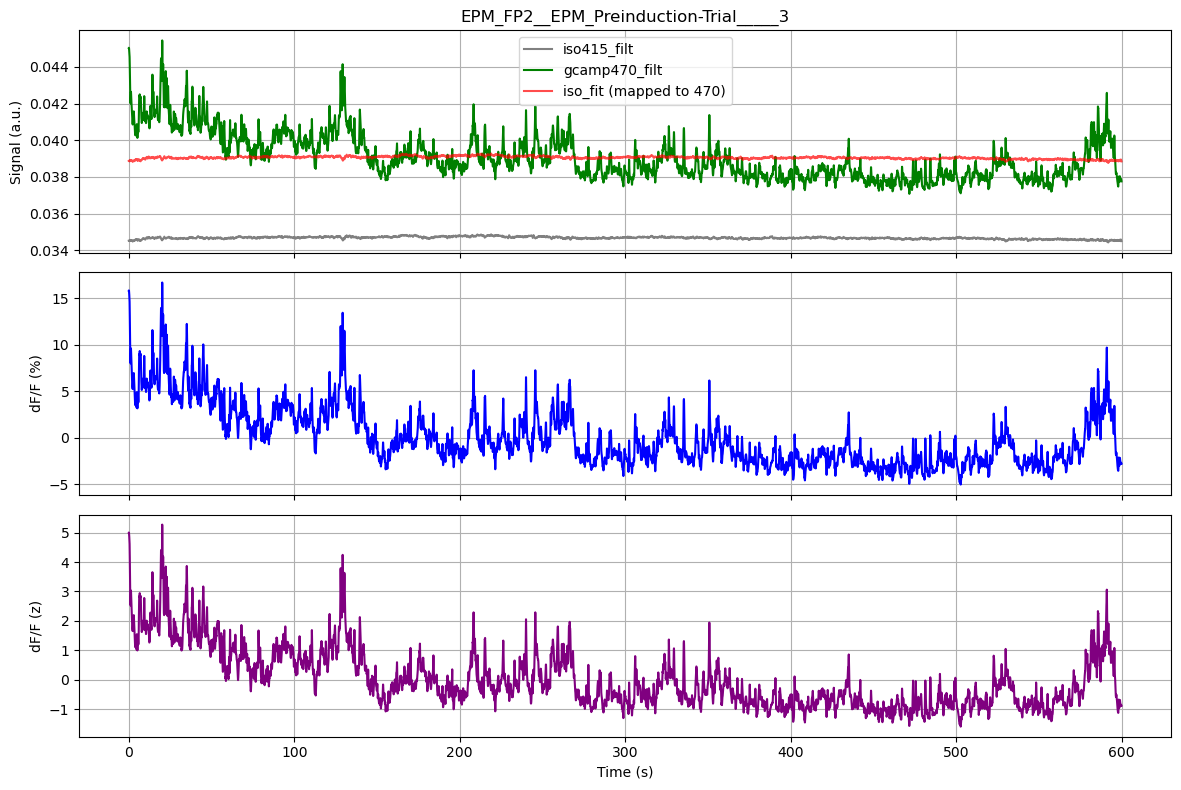

In [17]:
key = "EPM_FP2__EPM_Preinduction-Trial_____3"
df = preproc_trials[key]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Top: filtered signals and fitted baseline
axes[0].plot(df["Time_video"], df["iso415_filt"],   label="iso415_filt", color="gray")
axes[0].plot(df["Time_video"], df["gcamp470_filt"], label="gcamp470_filt", color="green")
axes[0].plot(df["Time_video"], df["iso_fit"],       label="iso_fit (mapped to 470)", color="red", alpha=0.7)
axes[0].set_ylabel("Signal (a.u.)")
axes[0].legend()
axes[0].set_title(key)

# Middle: ∆F/F
axes[1].plot(df["Time_video"], df["dFF"], color="blue")
axes[1].set_ylabel("dF/F (%)")

# Bottom: z-scored ∆F/F
axes[2].plot(df["Time_video"], df["dFF_z"], color="purple")
axes[2].set_ylabel("dF/F (z)")
axes[2].set_xlabel("Time (s)")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()


# CORRECTIONS TO ETHOVISION ETHOGRAM
I want to look at the ethovision behavioural data. Right now even if the animal quickly 'transitions' between a phase via the center points quickly jumping back and forth between zones, but the animal not actually fully moving - I want to account for those transitions. if the point transitions to another zone for less than 1 second, take that time spent in the given area, and change it to the previous area where the mouse spent more than 1 second. plot the new and old ethogram above and below one another for each mouse

# PERI EVENT PLOTS UNCORRECTED SIGNAL


In [18]:
# ==========================================================
# RAW 470 PERI-EVENT PLOTS (no correction)
# Detects entries into C1, C2, O1, O2, Neutral zones
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- PARAMETERS ----------
pre_s      = 2.0    # seconds before event
post_s     = 4.0    # seconds after event
min_stay_s = 1.0    # must stay ≥ 1 s in zone after entry
out_root   = main_dir / "Figures" / "PeriEventRaw"
out_root.mkdir(parents=True, exist_ok=True)

# ---------- SAFE HELPERS ----------
def _coerce_zone_binary(series: pd.Series) -> np.ndarray:
    """Convert EthoVision zone col to 0/1 uint8 (NaNs→0)."""
    vals = pd.to_numeric(series, errors="coerce").fillna(0.0).to_numpy(dtype=float)
    return (vals > 0.5).astype(np.uint8)

def _entrance_times(eth: pd.DataFrame, zone_col: str, fps: float, min_stay_s: float) -> np.ndarray:
    """Return timestamps for valid zone entries (stay ≥ min_stay_s)."""
    arr = _coerce_zone_binary(eth[zone_col])
    dif = np.diff(np.r_[0, arr])           # 1 at 0→1 transitions
    cand_idx = np.where(dif == 1)[0].astype(int)

    min_len = int(round(min_stay_s * fps))
    keep = []
    for i0 in cand_idx:
        j = i0
        while j < arr.size and arr[j] == 1:
            j += 1
        if (j - i0) >= min_len:
            keep.append(i0)

    # Frame-based time (robust to Time_s NaNs)
    t = np.arange(len(eth), dtype=float) / float(fps)
    return t[np.asarray(keep, dtype=int)]

def _best_match_column(available: list[str], wanted_tokens: list[str]) -> str | None:
    norm = {c: c.lower().replace(" ", "") for c in available}
    tokens = [t.lower().replace(" ", "") for t in wanted_tokens]
    for c, nc in norm.items():
        if all(tok in nc for tok in tokens):
            return c
    return None

def _zone_column_map(matched_cols: list[str]) -> dict:
    """Map zone keys (C1,C2,O1,O2,Neutral) → real EthoVision columns."""
    colmap = {}
    exact_targets = {
        "O1": "In zone 2(O1_prevC1 / Center-point)",
        "O2": "In zone 2(O2_prevC2 / Center-point)",
        "C1": "In zone 2(C1_prevO1 / Center-point)",
        "C2": "In zone 2(C2_prevO2 / Center-point)",
        "Neutral": "In zone 2(NeutralZone / Center-point)",
    }
    for k, exact in exact_targets.items():
        if exact in matched_cols:
            colmap[k] = exact
        else:
            toks = ["inzone2", k.lower()] if k in ("O1","O2","C1","C2") else ["inzone2","neutral"]
            g = _best_match_column(matched_cols, toks)
            if g:
                colmap[k] = g
    return colmap

def _collect_segments_raw(time_vec, signal_vec, evt_times, pre_s, post_s, fps):
    """Extract raw peri-event signal windows (no baseline)."""
    pre_n  = int(round(pre_s  * fps))
    post_n = int(round(post_s * fps))
    segs = []
    for ev in evt_times:
        idx = np.searchsorted(time_vec, ev)
        if idx >= pre_n and (idx + post_n) < len(signal_vec):
            segs.append(signal_vec[idx - pre_n : idx + post_n])
    if not segs:
        return np.empty((pre_n + post_n, 0))
    return np.column_stack(segs)

def _plot_peri_raw(mouse_id, zone_key, ERF, fps, out_dir):
    """Plot & save raw peri-event traces."""
    out_dir.mkdir(parents=True, exist_ok=True)
    pre_n, post_n = int(round(pre_s*fps)), int(round(post_s*fps))
    t = np.linspace(-pre_s, post_s, pre_n + post_n, endpoint=False)

    fig, ax = plt.subplots(figsize=(8,4))
    if ERF.shape[1] > 0:
        colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
        for i,c in enumerate(colors):
            ax.plot(t, ERF[:,i], color=c, alpha=0.35, lw=1)
        ax.plot(t, ERF.mean(1), color="k", lw=2.2, label="Mean")
        ax.legend(frameon=False, loc="upper right")
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set(title=f"{mouse_id}: entry into {zone_key}",
           xlabel="Time rel. to entry (s)",
           ylabel="Raw 470 signal (a.u.)")
    ax.grid(True)
    plt.tight_layout()
    out_png = out_dir / f"{mouse_id}__{zone_key}.png"
    plt.savefig(out_png, dpi=200)
    plt.close(fig)
    return out_png




# ---------- MAIN LOOP (robust, all mice + global summary) ----------
relax_edges = False      # allow partial windows near edges (pads with NaNs)
save_empty_plots = True  # save a stub plot even if no events
global_summary = []      # accumulate across all mice

def _segments_raw_debug(time_vec, signal_vec, evt_times, pre_s, post_s, fps):
    pre_n = int(round(pre_s*fps)); post_n = int(round(post_s*fps))
    n = len(signal_vec)
    ok_events, dropped_edges = 0, 0
    segs = []
    for ev in evt_times:
        idx = np.searchsorted(time_vec, ev)
        left = idx - pre_n; right = idx + post_n
        if left < 0 or right >= n:
            if relax_edges:
                left = max(0, left); right = min(n, right)
                seg = signal_vec[left:right].copy()
                L = pre_n + post_n
                if seg.size < L:
                    seg = np.concatenate([seg, np.full(L - seg.size, np.nan)])
                segs.append(seg); ok_events += 1
            else:
                dropped_edges += 1
            continue
        segs.append(signal_vec[left:right]); ok_events += 1
    ERF = np.column_stack(segs) if segs else np.empty((pre_n + post_n, 0))
    return ERF, ok_events, dropped_edges

def _plot_empty_stub(mouse_id, zone_key, fps, out_dir, note="No qualifying entries"):
    out_dir.mkdir(parents=True, exist_ok=True)
    pre_n = int(round(pre_s*fps)); post_n = int(round(post_s*fps))
    t = np.linspace(-pre_s, post_s, pre_n + post_n, endpoint=False)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.text(0.02, 0.9, note, transform=ax.transAxes)
    ax.set(title=f"{mouse_id}: entry into {zone_key}",
           xlabel="Time rel. to entry (s)", ylabel="Raw 470 signal (a.u.)")
    ax.grid(True)
    plt.tight_layout()
    out_png = out_root / mouse_id / f"{mouse_id}__{zone_key}.png"
    plt.savefig(out_png, dpi=200); plt.close(fig)

trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
print(f"[INFO] Found {len(trial_files)} trials")
for i_trial, eth_path in enumerate(trial_files, 1):
    try:
        fp_id = _read_export_and_get_fp_id(eth_path)
        print(f"\n--- [{i_trial}/{len(trial_files)}] {eth_path.name} → {fp_id} ---")

        # FP trim
        fp_folder = main_dir / fp_id
        fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)
        fp = pd.read_csv(fp_csv); fp = fp[fp["LedState"].isin([1,2])].copy()
        ts = pd.read_csv(ts_csv)
        start, stop = _get_video_window(ts)
        fp_trim = _trim_fp_to_window(fp, start=start, stop=stop)

        # LED2 channel/time
        gmask = fp_trim["LedState"] == 2
        g_time = fp_trim.loc[gmask,"Time_video"].to_numpy(float)
        if g_time.size < 3:
            print("[WARN] LED2 has too few samples; skipping")
            continue
        fps_eff = 1/np.mean(np.diff(g_time))
        chan = "G0" if "G0" in fp_trim.columns else next(
            c for c in fp_trim.columns
            if pd.api.types.is_numeric_dtype(fp_trim[c])
            and c not in {"SystemTimestamp","LedState","Time_video","Time_s","Timestamp"}
        )
        raw470 = fp_trim.loc[gmask, chan].to_numpy(float)

        # EthoVision
        eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, target_zone_labels, video_fps)
        print(f"[INFO] matched_cols: {matched_cols}")
        if not matched_cols:
            print("[WARN] No zone cols found"); continue
        colmap = _zone_column_map(matched_cols)
        print(f"[INFO] colmap: {colmap}")
        if not colmap:
            print("[WARN] Zone mapping failed"); continue

        mouse_dir = out_root / fp_id
        mouse_had_any = False

        for zone_key in ["C1","C2","O1","O2","Neutral"]:
            status = {"mouse": fp_id, "trial": eth_path.name, "zone": zone_key}
            if zone_key not in colmap:
                print(f"[INFO] {zone_key}: column not present"); 
                status |= {"rises":0,"pass_stay":0,"within_window":0,"edge_dropped":0,"note":"no_column"}
                global_summary.append(status)
                if save_empty_plots: _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir)
                continue

            # raw rises
            arr = _coerce_zone_binary(eth[colmap[zone_key]])
            rises = int(np.where(np.diff(np.r_[0, arr]) == 1)[0].size)
            # pass 1s stay
            idx_keep = _entrance_times(eth, colmap[zone_key], video_fps, min_stay_s)
            pass_stay = int(idx_keep.size)
            evt_times = idx_keep  # already timestamps from _entrance_times

            # segments and edge drops
            ERF, within, edge_dropped = _segments_raw_debug(
                time_vec=g_time, signal_vec=raw470, evt_times=evt_times,
                pre_s=pre_s, post_s=post_s, fps=fps_eff
            )
            print(f"[{fp_id} {zone_key}] rises={rises}, pass_stay={pass_stay}, "
                  f"within_window={within}, edge_dropped={edge_dropped}")

            status |= {"rises":rises, "pass_stay":pass_stay,
                       "within_window":within, "edge_dropped":edge_dropped,
                       "note":""}
            global_summary.append(status)

            if ERF.size == 0:
                if save_empty_plots:
                    _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir,
                                     note="No qualifying entries")
                continue

            _plot_peri_raw(fp_id, zone_key, ERF, fps_eff, mouse_dir)
            mouse_had_any = True

        if mouse_had_any:
            print(f"✅ Peri-event plots saved in {mouse_dir}")
        else:
            print(f"[INFO] No zones plotted for {fp_id} (empty or filtered); stub images may exist")

    except Exception as e:
        print(f"[WARN] {eth_path.name}: {e}")

# Write a single CSV with all mice/zones
summary_path = out_root / "ALL_mice_event_summary.csv"
pd.DataFrame(global_summary).to_csv(summary_path, index=False)
print(f"\n[INFO] Wrote summary: {summary_path}")


[INFO] Found 5 trials

--- [1/5] Raw data-EPM_Preinduction-Trial     1.xlsx → EPM_FP0 ---
[INFO] matched_cols: ['In zone 2(O1_prevC1 / Center-point)', 'In zone 2(O2_prevC2 / Center-point)', 'In zone 2(C1_prevO1 / Center-point)', 'In zone 2(C2_prevO2 / Center-point)', 'In zone 2(NeutralZone / Center-point)']
[INFO] colmap: {'O1': 'In zone 2(O1_prevC1 / Center-point)', 'O2': 'In zone 2(O2_prevC2 / Center-point)', 'C1': 'In zone 2(C1_prevO1 / Center-point)', 'C2': 'In zone 2(C2_prevO2 / Center-point)', 'Neutral': 'In zone 2(NeutralZone / Center-point)'}
[EPM_FP0 C1] rises=3, pass_stay=1, within_window=1, edge_dropped=0
[EPM_FP0 C2] rises=12, pass_stay=2, within_window=1, edge_dropped=1
[EPM_FP0 O1] rises=2, pass_stay=0, within_window=0, edge_dropped=0
[EPM_FP0 O2] rises=3, pass_stay=1, within_window=1, edge_dropped=0
[EPM_FP0 Neutral] rises=8, pass_stay=3, within_window=3, edge_dropped=0
✅ Peri-event plots saved in /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/Preinductio

KeyboardInterrupt: 

# CORRECTIONS TO FP TRACE

Fit biexponential function to isobestic trace

In [ ]:
# ==========================================================
# Batch: fit biexponential to 415 (FULL & CROPPED) for ALL trials
# Saves two PNGs per trial in Figures/Isosbestic_biexp_fits
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

# Reuse existing config or set safe defaults
try:
    main_dir
except NameError:
    main_dir = Path(".").resolve() / "Preinduction"

try:
    export_dir
except NameError:
    export_dir = main_dir / "Export files"

try:
    video_fps
except NameError:
    video_fps = 50.0

# Output folder
iso_fit_dir = (main_dir / "Figures" / "Isosbestic_biexp_fits")
iso_fit_dir.mkdir(parents=True, exist_ok=True)

def exp2(x, a, b, c, d):
    # MATLAB exp2: a*exp(b*x) + c*exp(d*x)
    return a * np.exp(b * x) + c * np.exp(d * x)

def _fit_and_save_iso(x_time: np.ndarray, y_iso: np.ndarray, title: str, out_png: Path):
    """Fit biexponential to isosbestic trace and save overlay plot."""
    m = np.isfinite(x_time) & np.isfinite(y_iso)
    x = np.asarray(x_time[m], dtype=float)
    y = np.asarray(y_iso[m], dtype=float)
    if x.size < 10:
        print(f"[WARN] {title}: not enough points to fit"); return

    xi  = np.arange(x.size, dtype=float)            # frame index for stability
    amp = np.ptp(y) if np.ptp(y) > 0 else (np.nanmax(y) - np.nanmin(y) if np.isfinite(y).any() else 1.0)
    if not np.isfinite(amp) or amp <= 0: amp = 1.0
    p0  = [amp, -1e-3, 0.5*amp, -1e-4]

    try:
        popt, _ = curve_fit(exp2, xi, y, p0=p0, maxfev=20000)
        y_fit = exp2(xi, *popt)
    except Exception as e:
        print(f"[WARN] {title}: fit failed ({e}); plotting raw only")
        y_fit = None

    fig, ax = plt.subplots(1, 1, figsize=(12, 3))
    ax.plot(x, y, lw=0.8, label="415 raw (isosbestic)")
    if y_fit is not None:
        ax.plot(x, y_fit, lw=1.2, label="biexponential fit (exp2)")
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Isosbestic (a.u.)")
    ax.grid(True); ax.legend(frameon=False)
    plt.tight_layout(); plt.savefig(out_png, dpi=200); plt.close(fig)

# ---------------- Run for ALL trials ----------------
trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
if not trial_files:
    print(f"[WARN] No 'Raw data-*.xlsx' files found in {export_dir}")

for eth_path in trial_files:
    try:
        # Identify FP files
        fp_id = _read_export_and_get_fp_id(eth_path)
        fp_folder = main_dir / fp_id
        if not fp_folder.is_dir():
            print(f"[WARN] {fp_id}: FP folder missing → {fp_folder}"); continue
        fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

        # Load full FP and keep only LED1/LED2 rows
        fp = pd.read_csv(fp_csv)
        if "LedState" not in fp.columns:
            print(f"[WARN] {fp_id}: no LedState column in FP CSV"); continue
        fp = fp[fp["LedState"].isin([1, 2])].copy()

        # Trim to video window for CROPPED fit
        ts = pd.read_csv(ts_csv)
        video_start, video_stop = _get_video_window(ts)
        fp_trim = _trim_fp_to_window(fp, start=video_start, stop=video_stop)

        # Choose numeric channel (same logic you use elsewhere)
        chan = "G0" if "G0" in fp_trim.columns else next(
            c for c in fp_trim.columns
            if pd.api.types.is_numeric_dtype(fp_trim[c])
            and c not in {"SystemTimestamp","LedState","Time_video","Time_s","Timestamp"}
        )

        # ---------- FULL trace (LED1 only) ----------
        fp_full_iso = fp.loc[fp["LedState"] == 1].copy()
        # full time vector (seconds from start)
        t_full = _build_time_vector_from_fp(fp_full_iso)
        if t_full.size:
            t_full = t_full - t_full[0]
        y_full = pd.to_numeric(fp_full_iso[chan], errors="coerce").to_numpy(float)

        # ---------- CROPPED trace (LED1 only) ----------
        fp_cropped_iso = fp_trim.loc[fp_trim["LedState"] == 1].copy()
        t_crop = fp_cropped_iso["Time_video"].to_numpy(float)
        y_crop = pd.to_numeric(fp_cropped_iso[chan], errors="coerce").to_numpy(float)

        # Filenames
        trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
        base      = f"{fp_id}__{trial_stub}"
        out_full  = iso_fit_dir / f"{base}__iso415_fit_FULL.png"
        out_crop  = iso_fit_dir / f"{base}__iso415_fit_CROPPED.png"

        # Fit + save both
        _fit_and_save_iso(t_full, y_full,  title=f"{fp_id} — {trial_stub} (FULL 415)",    out_png=out_full)
        _fit_and_save_iso(t_crop, y_crop,  title=f"{fp_id} — {trial_stub} (CROPPED 415)", out_png=out_crop)

        print(f"🖼  {fp_id}: saved {out_full.name}, {out_crop.name}")

    except StopIteration:
        print(f"[WARN] {eth_path.name}: could not infer numeric channel")
    except Exception as e:
        print(f"[WARN] {eth_path.name}: {e}")


In [ ]:
# ==========================================================
# Batch add-on: robustly scale 415 fit to 470 channel
# Saves two PNGs per trial in Figures/ScaledIso_to_470
# ==========================================================
from pathlib import Path
from sklearn.linear_model import HuberRegressor
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

scaled_dir = (main_dir / "Figures" / "ScaledIso_to_470")
scaled_dir.mkdir(parents=True, exist_ok=True)

def _exp2(x, a, b, c, d):
    return a * np.exp(b * x) + c * np.exp(d * x)

def _fit_iso_return_params(x_time: np.ndarray, y_iso: np.ndarray):
    """
    Fit exp2 on isosbestic using frame-index (like MATLAB temp_x).
    Returns (popt, x_valid, y_valid, y_fit) or (None, ... ) if fit fails.
    """
    m = np.isfinite(x_time) & np.isfinite(y_iso)
    x = np.asarray(x_time[m], float)
    y = np.asarray(y_iso[m], float)
    if x.size < 10:
        return None, x, y, None

    xi  = np.arange(x.size, dtype=float)
    amp = np.ptp(y) if np.ptp(y) > 0 else (np.nanmax(y) - np.nanmin(y) if np.isfinite(y).any() else 1.0)
    if not np.isfinite(amp) or amp <= 0: amp = 1.0
    p0  = [amp, -1e-3, 0.5*amp, -1e-4]

    try:
        popt, _ = curve_fit(_exp2, xi, y, p0=p0, maxfev=20000)
        y_fit = _exp2(xi, *popt)
        return popt, x, y, y_fit
    except Exception:
        return None, x, y, None

def _scale_and_save_iso_to_470(title: str,
                               t415: np.ndarray, y415: np.ndarray,
                               t470: np.ndarray, y470: np.ndarray,
                               out_png: Path):
    """
    1) Fit exp2 to 415 (frame-index domain).
    2) Interpolate 415-fit to 470 timestamps.
    3) Robust linear scaling (Huber) to match 470.
    4) Save overlay plot (470 raw + scaled 415 fit).
    """
    popt, x415, y415v, y415_fit = _fit_iso_return_params(t415, y415)

    fig, ax = plt.subplots(1, 1, figsize=(12, 3))

    if popt is None or y415_fit is None or x415.size < 3:
        # Fall back: just show 470 raw if fit failed
        ax.plot(t470, y470, lw=0.9, label="470 nm raw")
        ax.set_title(title + " (fit failed)")
    else:
        # Map 415 time -> frame index used for fitting
        # x415 are the valid-time samples used to build xi = 0..N-1
        xi = np.arange(x415.size, dtype=float)
        # Build time->index mapping on the 415 valid samples
        try:
            idx_from_time = interp1d(x415, xi, kind="linear",
                                     fill_value="extrapolate", assume_sorted=False)
            x470_idx = idx_from_time(t470)
            iso_fit_at_470 = _exp2(x470_idx, *popt)

            # Robust linear scaling
            y470v = pd.to_numeric(y470, errors="coerce")
            mask = np.isfinite(iso_fit_at_470) & np.isfinite(y470v)
            if mask.sum() < 10:
                ax.plot(t470, y470, lw=0.9, label="470 nm raw")
                ax.set_title(title + " (not enough overlap for scaling)")
            else:
                huber = HuberRegressor()
                huber.fit(iso_fit_at_470[mask].reshape(-1, 1), y470v[mask].to_numpy())
                slope = float(huber.coef_[0])
                intercept = float(huber.intercept_)
                y470_pred = intercept + slope * iso_fit_at_470

                # Plot overlays
                ax.plot(t470, y470, lw=0.8, label="470 nm raw (Ca-dependent)")
                ax.plot(t470, y470_pred, lw=1.2, label="Scaled 415 nm fit (robust)")
                ax.set_title(title)

        except Exception as e:
            # Any interpolation/scaling failure → show 470 only
            ax.plot(t470, y470, lw=0.9, label="470 nm raw")
            ax.set_title(title + f" (scaling failed)")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Signal (a.u.)")
    ax.grid(True); ax.legend(frameon=False)
    plt.tight_layout(); plt.savefig(out_png, dpi=200); plt.close(fig)

# ---------------- Apply to ALL trials (FULL + CROPPED) ----------------
# Reuse the same loop inputs the batch already prepared
trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
for eth_path in trial_files:
    try:
        # Resolve IDs/paths exactly as you did above
        fp_id = _read_export_and_get_fp_id(eth_path)
        fp_folder = main_dir / fp_id
        if not fp_folder.is_dir(): 
            continue
        fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

        fp = pd.read_csv(fp_csv)
        if "LedState" not in fp.columns:
            continue
        fp = fp[fp["LedState"].isin([1, 2])].copy()

        ts = pd.read_csv(ts_csv)
        video_start, video_stop = _get_video_window(ts)
        fp_trim = _trim_fp_to_window(fp, start=video_start, stop=video_stop)

        # Channel selection (same logic)
        chan = "G0" if "G0" in fp_trim.columns else next(
            c for c in fp_trim.columns
            if pd.api.types.is_numeric_dtype(fp_trim[c])
            and c not in {"SystemTimestamp","LedState","Time_video","Time_s","Timestamp"}
        )

        # -------- FULL (LED1 & LED2) --------
        fp_full_iso = fp.loc[fp["LedState"] == 1].copy()
        t_full_415  = _build_time_vector_from_fp(fp_full_iso)
        if t_full_415.size:
            t_full_415 = t_full_415 - t_full_415[0]
        y_full_415  = pd.to_numeric(fp_full_iso[chan], errors="coerce").to_numpy(float)

        fp_full_470 = fp.loc[fp["LedState"] == 2].copy()
        t_full_470  = _build_time_vector_from_fp(fp_full_470)
        if t_full_470.size:
            t_full_470 = t_full_470 - t_full_470[0]
        y_full_470  = pd.to_numeric(fp_full_470[chan], errors="coerce").to_numpy(float)

        # -------- CROPPED (LED1 & LED2) --------
        fp_crop_iso = fp_trim.loc[fp_trim["LedState"] == 1].copy()
        t_crop_415  = fp_crop_iso["Time_video"].to_numpy(float)
        y_crop_415  = pd.to_numeric(fp_crop_iso[chan], errors="coerce").to_numpy(float)

        fp_crop_470 = fp_trim.loc[fp_trim["LedState"] == 2].copy()
        t_crop_470  = fp_crop_470["Time_video"].to_numpy(float)
        y_crop_470  = pd.to_numeric(fp_crop_470[chan], errors="coerce").to_numpy(float)

        # Filenames
        trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
        base      = f"{fp_id}__{trial_stub}"
        out_full  = scaled_dir / f"{base}__ScaledIsoTo470_FULL.png"
        out_crop  = scaled_dir / f"{base}__ScaledIsoTo470_CROPPED.png"

        # Scale & save overlays
        _scale_and_save_iso_to_470(
            title=f"{fp_id} - {trial_stub} (FULL)",
            t415=t_full_415, y415=y_full_415,
            t470=t_full_470, y470=y_full_470,
            out_png=out_full
        )

        _scale_and_save_iso_to_470(
            title=f"{fp_id} - {trial_stub} (CROPPED)",
            t415=t_crop_415, y415=y_crop_415,
            t470=t_crop_470, y470=y_crop_470,
            out_png=out_crop
        )

        print(f"🖼  {fp_id}: saved {out_full.name}, {out_crop.name}")

    except StopIteration:
        print(f"[WARN] {eth_path.name}: could not infer numeric channel")
    except Exception as e:
        print(f"[WARN] {eth_path.name}: {e}")
